**Name:** Aarya Tiwari



In [23]:
!pip install -q pillow matplotlib scikit-image numpy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from skimage import color as skcolor
from google.colab import files
import io
print("✅ All libraries loaded.")

✅ All libraries loaded.


In [29]:
#golden color references and Enhanced references with multiple shades per color
#now we have created a list of lists
COLOR_REFERENCES_LAB = {
    "White":   [[100.0, 0.0, 0.0], [95.0, -2.0, 3.0]],      # pure + off-white
    "Black":   [[0.0, 0.0, 0.0], [10.0, 0.0, 0.0]],         # pure + near-black
    "Gray":    [[50.0, 0.0, 0.0], [70.0, 0.0, 0.0], [30.0, 0.0, 0.0]],
    "Red":     [[53.2, 80.1, 67.2], [40.0, 60.0, 40.0]],     # red + burgundy
    "Green":   [[87.7, -86.2, 83.2], [50.0, -50.0, 40.0]],   # green + dark green
    "Yellow":  [[97.1, -21.6, 94.5], [85.0, -10.0, 70.0]],   # yellow + mustard/dark yellow color
    "Blue":    [[32.3, 79.2, -107.9], [50.0, 30.0, -60.0], [25.0, 10.0, -40.0]],  # pure + navy + sky
    "Brown":   [[36.1, 22.3, 27.8], [45.0, 25.0, 35.0]],     # brown + tan/dark orange hues
    "Purple":  [[48.3, 64.1, -38.6], [35.0, 40.0, -30.0]],   # purple + lavender
    "Pink":    [[77.8, 48.5, -10.8], [85.0, 35.0, -5.0]],    # pink + light pink
    "Orange":  [[69.7, 42.4, 72.4], [60.0, 35.0, 55.0]],     # orange + peach
}

#  modify classify_pixels to find min distance to any reference for that color
def classify_pixels_v2(img_lab_flat):
    """Find closest color category by checking all reference points"""
    N = img_lab_flat.shape[0]
    min_distances = np.full((N, len(ALL_CLASSES)), np.inf)

    for i, cls in enumerate(ALL_CLASSES):
        for ref in COLOR_REFERENCES_LAB[cls]:
            ref_array = np.array(ref)
            diffs = img_lab_flat - ref_array
            dists = np.sqrt(np.sum(diffs ** 2, axis=1))
            min_distances[:, i] = np.minimum(min_distances[:, i], dists)

    return np.argmin(min_distances, axis=1)

# Ordered list — determines bar/pie order in the chart
ALL_CLASSES = [
    "White", "Black", "Gray",
    "Red", "Orange", "Yellow",
    "Green", "Blue", "Purple",
    "Pink", "Brown",
]
#for the chart
DISPLAY_COLORS = {
    "White":   "#FFFFFF",
    "Black":   "#000000",
    "Gray":    "#808080",
    "Red":     "#FF0000",
    "Green":   "#00FF00",
    "Yellow":  "#FFFF00",
    "Blue":    "#0000FF",
    "Brown":   "#8B4513",
    "Purple":  "#800080",
    "Pink":    "#FFC0CB",
    "Orange":  "#FFA500",
}

Multi-reference classifier with all 11 colors (Blue & Purple included)
 Upload your image(s). You can select multiple files at once.


Saving TestImage1.jpg to TestImage1 (1).jpg
Saving TestImage2.jpg to TestImage2 (1).jpg
Saving TestImage3.jpg to TestImage3 (1).jpg
Saving TestImage4.jpg to TestImage4 (1).jpg

 Analyzing: TestImage1 (1).jpg

Color      Percentage  Visual Bar
--------------------------------------------------
White          0.19%  
Black         42.96%  █████████████████████
Gray          32.42%  ████████████████
Red            0.00%  (no pixels detected)
Orange         1.11%  
Yellow         3.25%  █
Green          0.00%  (no pixels detected)
Blue           0.00%  (no pixels detected)
Purple         0.00%  (no pixels detected)
Pink           0.00%  (no pixels detected)
Brown         20.08%  ██████████


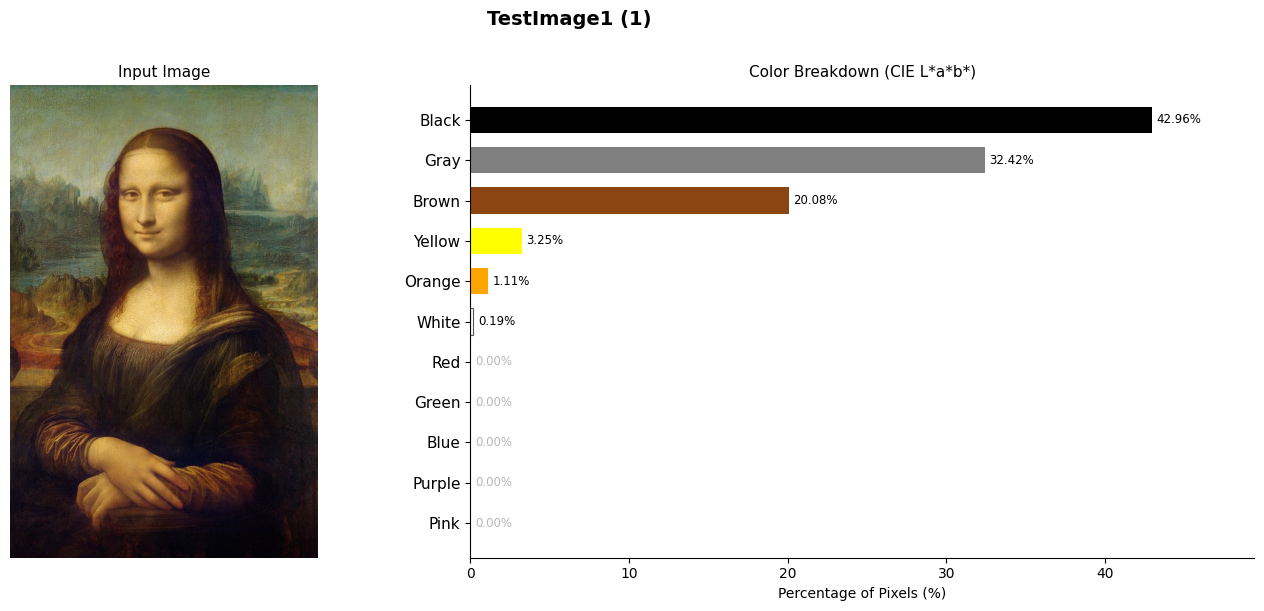

 Chart saved as 'TestImage1_(1)_chart.png'

 Colors not detected: Red, Green, Blue, Purple, Pink

 Analyzing: TestImage2 (1).jpg

Color      Percentage  Visual Bar
--------------------------------------------------
White          2.01%  █
Black         48.41%  ████████████████████████
Gray          33.29%  ████████████████
Red            1.86%  
Orange         1.25%  
Yellow         1.80%  
Green          0.44%  
Blue           0.10%  
Purple         0.00%  (no pixels detected)
Pink           0.94%  
Brown          9.90%  ████


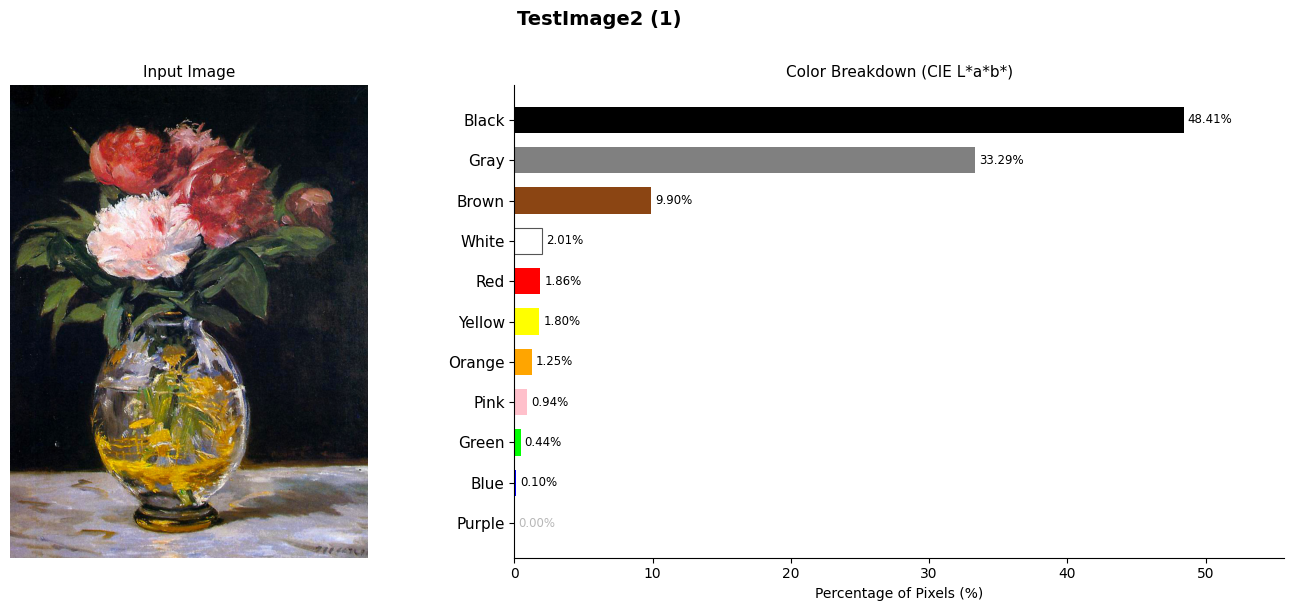

 Chart saved as 'TestImage2_(1)_chart.png'

 Colors not detected: Purple

 Analyzing: TestImage3 (1).jpg

Color      Percentage  Visual Bar
--------------------------------------------------
White          0.05%  
Black          0.82%  
Gray          49.16%  ████████████████████████
Red            8.26%  ████
Orange         4.17%  ██
Yellow        10.07%  █████
Green          8.29%  ████
Blue           0.81%  
Purple         0.08%  
Pink           1.02%  
Brown         17.27%  ████████


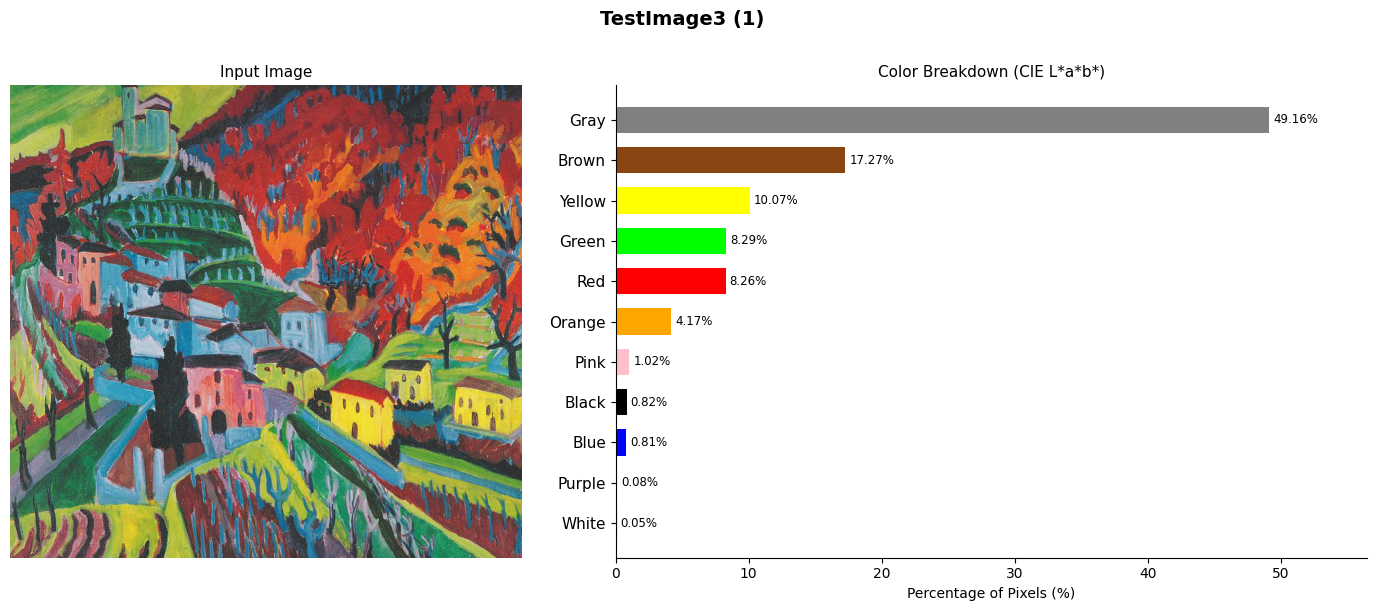

 Chart saved as 'TestImage3_(1)_chart.png'

 Analyzing: TestImage4 (1).jpg

Color      Percentage  Visual Bar
--------------------------------------------------
White         11.00%  █████
Black          4.38%  ██
Gray          59.81%  █████████████████████████████
Red            0.01%  
Orange         1.07%  
Yellow        13.41%  ██████
Green          3.51%  █
Blue           0.57%  
Purple         0.00%  (no pixels detected)
Pink           0.00%  (no pixels detected)
Brown          6.25%  ███


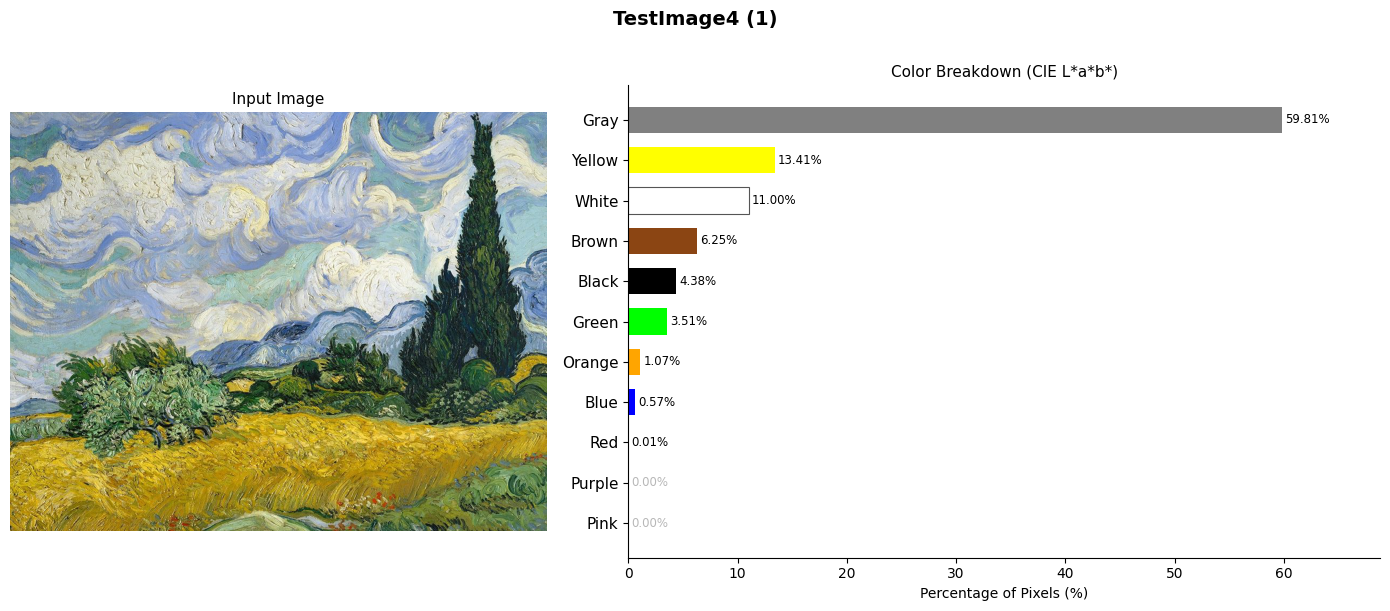

 Chart saved as 'TestImage4_(1)_chart.png'

 Colors not detected: Purple, Pink


In [32]:

def classify_pixels_multiref(img_lab_flat):
    """
    Classify pixels using multiple reference points per color.
    Each pixel gets assigned to the color with the closest reference point.

    img_lab_flat : (N, 3) float array of Lab values
    returns      : (N,) int array of class indices
    """
    N = img_lab_flat.shape[0]
    num_classes = len(ALL_CLASSES)

    # Initialize with large numbers
    min_distances = np.full((N, num_classes), np.inf)

    # For each color class, check all its reference points
    for i, cls in enumerate(ALL_CLASSES):
        ref_points = COLOR_REFERENCES_LAB[cls]  # List of [L, a, b] triplets

        for ref in ref_points:
            ref_array = np.array(ref).reshape(1, 3)  # (1, 3)
            # Calculate Euclidean distance between all pixels and this reference
            diffs = img_lab_flat - ref_array
            distances = np.sqrt(np.sum(diffs ** 2, axis=1))  # (N,)

            # Keep the minimum distance to any reference point of this color
            min_distances[:, i] = np.minimum(min_distances[:, i], distances)

    # Return the index of the color with minimum distance
    return np.argmin(min_distances, axis=1)

def analyze_image(img_path_or_pil):
    """
    Accepts a file path string OR a PIL Image object.
    Returns a dict {color_name: percentage} for ALL 11 colors,
    and the PIL image.
    """

    if isinstance(img_path_or_pil, str):
        pil_img = Image.open(img_path_or_pil).convert("RGB")
    else:
        pil_img = img_path_or_pil.convert("RGB")

    #  Downsample for speed (keep ≤ 300 px on longest side)
    MAX_DIM = 300
    w, h = pil_img.size
    scale = min(MAX_DIM / max(w, h), 1.0)
    small = pil_img.resize(
        (int(w * scale), int(h * scale)),
        Image.Resampling.LANCZOS
    )

    # RGB [0,255] → RGB [0,1] → CIE L*a*b*
    rgb_array  = np.array(small, dtype=np.float32) / 255.0   # (H, W, 3)
    lab_array  = skcolor.rgb2lab(rgb_array)                   # (H, W, 3)
    lab_flat   = lab_array.reshape(-1, 3)                     # (N, 3)

    #Classify every pixel using multi-reference
    indices    = classify_pixels_multiref(lab_flat)
    total_px   = len(indices)

    #Count & convert to percentages for ALL 11 colors
    results = {}
    for i, cls in enumerate(ALL_CLASSES):
        count = np.sum(indices == i)
        pct   = round(100.0 * count / total_px, 2)
        results[cls] = pct

    return results, pil_img

def plot_results(results, pil_img, title="Color Analysis"):
    """
    Plots a side-by-side figure:
      left  — original image
      right — horizontal bar chart of ALL 11 color percentages
    """
    # Keep ALL 11 colors (including zeros) for consistent display
    # Sort by percentage descending
    sorted_items = sorted(results.items(), key=lambda x: x[1], reverse=True)
    labels  = [item[0] for item in sorted_items]
    values  = [item[1] for item in sorted_items]
    colors  = [DISPLAY_COLORS[lbl] for lbl in labels]
    edge_c  = ["#555555" if lbl == "White" else "none" for lbl in labels]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6),
        gridspec_kw={"width_ratios": [1, 1.4]}
    )
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    #Left: original image
    axes[0].imshow(pil_img)
    axes[0].axis("off")
    axes[0].set_title("Input Image", fontsize=11)

    # Right: horizontal bar chart
    ax = axes[1]
    bars = ax.barh(
        range(len(labels)), values,
        color=colors,
        edgecolor=edge_c,
        linewidth=0.8,
        height=0.65,
    )

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=11)
    ax.invert_yaxis()                          # largest bar at top
    ax.set_xlabel("Percentage of Pixels (%)", fontsize=10)
    ax.set_xlim(0, max(values) * 1.15)         # room for labels
    ax.set_title("Color Breakdown (CIE L*a*b*)", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

    # Percentage labels at bar end
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(
                bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}%",
                va="center", ha="left", fontsize=8.5
            )
        else:
            # Show zero values in lighter text
            ax.text(
                bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"0.00%",
                va="center", ha="left", fontsize=8.5,
                color="#999999", alpha=0.7
            )

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_chart.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f" Chart saved as '{title.replace(' ', '_')}_chart.png'")

def print_color_table(results):
    """Print a formatted table with ALL 11 colors and visual bars"""
    print(f"\n{'Color':<10} {'Percentage':>10}  {'Visual Bar'}")
    print("-" * 50)

    for cls in ALL_CLASSES:
        pct = results[cls]
        if pct > 0:
            # Create visual bar (█ = 2%)
            bar = "█" * min(int(pct / 2), 50)  # Cap at 50 bars
            print(f"{cls:<10} {pct:>8.2f}%  {bar}")
        else:
            print(f"{cls:<10} {pct:>8.2f}%  (no pixels detected)")

print("Multi-reference classifier with all 11 colors (Blue & Purple included)")

#Upload & analyze images
from google.colab import files

print(" Upload your image(s). You can select multiple files at once.")
uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    print(f"\n{'='*60}")
    print(f" Analyzing: {filename}")
    print(f"{'='*60}")

    pil_img = Image.open(io.BytesIO(file_bytes))
    results, img = analyze_image(pil_img)

    # Pretty-print table with ALL 11 colors
    print_color_table(results)

    # Generate and save chart
    title = filename.rsplit(".", 1)[0]  # strip extension
    plot_results(results, img, title=title)

    # Show which colors were missing
    missing = [cls for cls in ALL_CLASSES if results[cls] == 0]
    if missing:
        print(f"\n Colors not detected: {', '.join(missing)}")